In [1]:
from utils_jupyter import load_hydra_config_with_params
from pathlib import Path
import json
from typing import Any, Iterable, List, Optional, Union
import sys
from omegaconf import OmegaConf, DictConfig, ListConfig, open_dict
import numpy as np
import matplotlib.pyplot as plt
MODEL_NAME = 'llama-3-8b'
PROBE = 'sawmil'
DATASET_NAME = 'cities_loc'
TASK = -1

path = Path('outputs') / 'probes' / PROBE / MODEL_NAME /f'{ DATASET_NAME }_search_task-{str(TASK)}' / 'manifests'
path.exists(), path

(True,
 PosixPath('outputs/probes/sawmil/llama-3-8b/cities_loc_search_task--1/manifests'))

In [2]:
cfg = load_hydra_config_with_params(model=MODEL_NAME, probe=PROBE, datapack=DATASET_NAME, task =1, config_name='probe_sil')
cfg['probe']

{'name': 'sawmil', 'init_params': {'verbose': True, 'kernel': 'linear_av', 'C': 1.0, 'scale_C': True, 'sv_cutoff': 1e-07}, 'param_grid': {'C': [0.05, 0.1, 0.5, 1, 10]}, 'normalize_data': True, 'with_bags': True, 'max_bag_size': 10, 'assume_known_positives': True, 'num_known_positives': 2, 'train_bag_limit': 1800}

In [3]:

from runners.runner_md import MDProbeRunner
from runners.runner_svm import SVMProbeRunner
from runners.runner_sawmil import SawmilProbeRunner
from runners.mc_runner_sawmil import MulticlassMILRunner

runner = MulticlassMILRunner(cfg=cfg)
runner = runner.load(output_dir=Path('outputs') / 'probes' / PROBE / MODEL_NAME /f'{ DATASET_NAME }_search_task-{str(TASK)}', layer_id=10)
bag = [np.random.randn(10, 4096) for _ in range(5)]
runner.bag_predict(bag), runner.predict(bag), runner.inst_predict(bag)

/Users/carlomarx/.local/share/virtualenvs/belief-representation-dS6b1P8F-python/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AttributeError: Can't get attribute 'MulticlassMIL' on <module 'probes.multiclass' from '/Users/carlomarx/Documents/GitHub/trillema-of-truth/probes/multiclass.py'>

In [5]:
bag = [np.random.randn(10, 4096) for _ in range(5)]
runner.bag_predict(bag), runner.predict(bag), runner.inst_predict(bag)

(array([ True,  True,  True,  True,  True]),
 array([ True,  True,  True, False, False]),
 array([ True,  True,  True, False, False]))

In [ ]:
import importlib
from pathlib import Path
import json
from typing import Any, Iterable, List, Optional, Union
import sys
from packaging import version
class ExperimentData:
    '''
    Class to manage and access experimental data for different models, probes, datasets, and tasks.
    '''
    def __init__(self, 
                 model_name:str, 
                 probe_name:str, 
                 dataset_name:str, 
                 task: int, 
                 with_search:bool = True):
        '''
        Initialize the ExperimentData object with the specified parameters.
        Args:
            model_name (str): The name of the model.
            probe_name (str): The name of the probe.
            dataset_name (str): The name of the dataset.
            task (int): The task number.
            with_search (bool): Whether to include search in the path construction.
        '''
        self.model_name = model_name
        self.probe_name = probe_name
        self.dataset_name = dataset_name
        self.task = task
        self.with_search = with_search
        
    @property
    def base_path(self) -> Path:
        '''
        Construct the base path for the experiment data based on the provided parameters.
        Returns:
            Path: The constructed base path.
        '''
        if self.with_search:
            return Path('outputs') / 'probes' / self.probe_name / self.model_name / f'{self.dataset_name}_search_task-{str(self.task)}'
        else:
            return Path('outputs') / 'probes' / self.probe_name / self.model_name / f'{self.dataset_name}_task-{str(self.task)}'
        
    @property
    def absolute_path(self) -> Path:
        return self.base_path.absolute()
    
    def layer_exists(self, layer:int) -> bool:
        '''Check if the manifest file for a given layer exists.
        Args:
            layer (int): The layer number to check.
        Returns:
            bool: True if the manifest file exists, False otherwise.
        '''
        path = self.base_path / 'manifests' / f'manifest_{str(layer)}.json'
        return path.exists()
    
    def load_manifest(self, layer:int) -> dict:
        '''Load the manifest file for a given layer.
        Args:
            layer (int): The layer number to load the manifest for.
        Returns:
            dict: The content of the manifest file as a dictionary.
        '''
        assert self.layer_exists(layer), f"The experimental data for layer {layer} does not exist. Available layers: {self.available_layers()}"
        with open(self.base_path / 'manifests' / f'manifest_{str(layer)}.json', 'r') as f:
            manifest = json.load(f)
        return manifest
    
    @property
    def available_layers(self) -> List[int]:
        '''Get a list of available layers for which manifest files exist.
        Returns:
            list[int]: A list of layer numbers that have manifest files.
        '''
        manifests_path = self.base_path / 'manifests'
        if not manifests_path.exists():
            return []
        
        layer_files = manifests_path.glob('manifest_*.json')
        layers = [int(f.stem.split('_')[1]) for f in layer_files if f.stem.split('_')[1].isdigit()]
        return sorted(layers)
    
    def available_subexperiments(self) -> List[str]:
        '''Get a list of available statistics for which stats files exist.
        Returns:
            list[str]: A list of statistic names that have stats files.
        '''
        folders = [x for x in self.base_path.iterdir() if x.is_dir()]
        folders = [x.name for x in folders if x.name.startswith('g_')]
        return sorted(folders)

    def best_layer(self, keys: List[str] = ['conformal', 'wmcc'], path: Optional[Path] = None) -> int:
        '''Determine the best layer based on a specified metric.
        Args:
            keys (list of str): The key or list of keys to navigate through the JSON structure to find the metric.
            path (Path, optional): The base path to the experiment data. If None, uses the default base path.
        Returns:
            int: The layer number that has the highest value for the specified metric.
        '''
        results = {}
        for layer in self.available_layers:
            metric = self.read_metrics(layer, keys, path=path)
            results[layer] = metric[0]
        return max(results, key=results.get)
    
    def read_metrics(self, layer_id: int,         
                keys: Optional[Union[str, Iterable[str]]] = None,
                default: Any = ...,
                path: Optional[Path] = None) -> Any:
        '''Read the metrics from the JSON file for a specific layer.
        Args:
            layer_id (int): The layer number to read metrics for.
            keys (str or list of str, optional): The key or list of keys to navigate through the JSON structure. If None, returns the entire JSON content.
            default (any, optional): The default value to return if the specified key path does not exist. If not provided and the key path is not found, a KeyError is raised.
            path (Path, optional): The base path to the experiment data. If None, uses the default base path.
        Returns:
            any: The value corresponding to the specified key path, or the entire JSON content if keys is None.
        Raises:
            KeyError: If the specified key path does not exist and no default value is provided.
            AssertionError: If the manifest file for the specified layer does not exist.
        '''
        assert self.layer_exists(layer_id), f"The experimental data for layer {layer_id} does not exist. Available layers: {self.available_layers()}"
        
        
        if path is not None:
            assert path.exists(), f"The provided path {str(path)} does not exist."
            path = Path(path) 
        else:
            path = self.base_path  
        with open(path / 'manifests' / f'manifest_{str(layer_id)}.json', 'r') as f:
            metric_path = json.load(f)['paths']['metrics']
            
        with open(metric_path, 'r') as f:
            data = json.load(f)
        if keys is None:
            return data

        # Normalize keys to a list
        if isinstance(keys, str):
            keys = [keys]
        else:
            keys = list(keys)

        cur = data
        for k in keys:
            if isinstance(cur, dict) and k in cur:
                cur = cur[k]
            else:
                if default is ...:
                    path_so_far = "/".join(keys)
                    raise KeyError(
                        f"Key path '{path_so_far}' not found (stopped at '{k}')."
                    )
                return default
        return cur
    
    def validate_manifest(self, layer_id: int, path: Optional[Path] = None) -> bool:
        '''Validate the manifest file for a specific layer.
        Args:
            layer_id (int): The layer number to validate the manifest for.
            path (Path, optional): The base path to the experiment data. If None, uses the default base path.
        Returns:
            bool: True if the manifest file is valid, False otherwise.  
        '''
        assert self.layer_exists(layer_id), f"The experimental data for layer {layer_id} does not exist. Available layers: {self.available_layers()}"
        manifest = self.load_manifest(layer_id)['env']
        not_installed = []
        not_matching = []
        for pkg, required_version in manifest.items():
            if pkg == 'python':
                v = ".".join(map(str, sys.version_info[:3]))
                if version.parse(v) == version.parse(required_version):
                    print(f'python: {v} (matches manifest)')
                elif version.parse(v) != version.parse(required_version):
                    print(f"python: installed {v}, but manifest requires {required_version}")
                    not_matching.append(pkg)
                continue
                
            try:
                # dynamically import the module
                mod = importlib.import_module(pkg)
                installed_version = getattr(mod, "__version__", None)
            except ModuleNotFoundError:
                print(f"{pkg}: not installed (expected {required_version})")
                not_installed.append(pkg)
                continue
            if version.parse(installed_version) == version.parse(required_version):
                print(f'{pkg}: installed {installed_version} matches manifest')
            elif version.parse(installed_version) != version.parse(required_version):
                print(f"{pkg}: installed {installed_version}, but manifest requires {required_version}")
                not_matching.append(pkg)
        if not_installed or not_matching:
            return False
        return True

In [190]:
".".join(map(str, sys.version_info[:3]))

'3.11.9'

In [191]:
eD.base_path.absolute()

PosixPath('/Users/carlomarx/Documents/GitHub/trillema-of-truth/outputs/probes/mean_diff/llama-3-8b/cities_loc_search_task-3')

In [192]:
eD.best_layer(keys=['bag', 'default', 'wmcc'], path = eD.base_path / 'g_cities_loc')
eD.read_metrics(14, keys=['bag', 'conformal', 'wmcc'], path = eD.base_path / 'g_cities_loc')

[0.0, 0.0, 0.0]

In [193]:
eD = ExperimentData(MODEL_NAME, PROBE, DATASET_NAME, TASK, with_search=True)
eD.layer_exists(0), eD.available_subexperiments()
# eD.read_metrics(5)
eD.read_metrics(15)
eD.read_metrics(15, keys=['bag', 'default', 'wmcc'], path = eD.base_path / 'g_cities_loc'), eD.read_metrics(15, keys=[ 'default', 'wmcc'])
eD.load_manifest(15)
# eD.available_layers

{'layer_id': 15,
 'paths': {'config': 'outputs/probes/mean_diff/llama-3-8b/cities_loc_search_task-3/config.json',
  'metrics': 'outputs/probes/mean_diff/llama-3-8b/cities_loc_search_task-3/metrics_15.json',
  'coef': 'outputs/probes/mean_diff/llama-3-8b/cities_loc_search_task-3/coef_15.npy',
  'bias': 'outputs/probes/mean_diff/llama-3-8b/cities_loc_search_task-3/bias_15.npy',
  'preds': 'outputs/probes/mean_diff/llama-3-8b/cities_loc_search_task-3/y_hat_15.npy',
  'estimator': 'outputs/probes/mean_diff/llama-3-8b/cities_loc_search_task-3/estimator_15.joblib',
  'scaler': 'outputs/probes/mean_diff/llama-3-8b/cities_loc_search_task-3/scaler_15.joblib',
  'transformer': None,
  'calibrator': 'outputs/probes/mean_diff/llama-3-8b/cities_loc_search_task-3/calibrator_15.joblib'},
 'shapes': {'coef': [4096], 'bias': [], 'y_hat': [1855], 'y_true': [1855]},
 'dtypes': {'coef': 'float64',
  'bias': 'float64',
  'y_hat': 'float64',
  'y_true': 'int32'},
 'env': {'python': '3.12.4',
  'numpy': '2.3

In [194]:
eD.validate_manifest(15)

python: installed 3.11.9, but manifest requires 3.12.4
numpy: installed 1.26.4, but manifest requires 2.3.3
joblib: installed 1.5.1, but manifest requires 1.5.2
hydra: installed 1.3.2 matches manifest
sklearn: installed 1.5.1, but manifest requires 1.7.2
scipy: installed 1.14.0, but manifest requires 1.16.2
polars: installed 1.30.0, but manifest requires 1.32.2
pandas: installed 2.2.3, but manifest requires 2.3.2
torch: installed 2.4.1, but manifest requires 2.5.1+cu121


False

In [167]:
def load_manifests(path):
    ids = range(100)
    import json
    manifests = []
    for id in ids:
        try:
            with open(path / f"manifest_{id}.json", 'r') as f:
                manifest = json.load(f)
                manifests.append(manifest)
        except FileNotFoundError:
            continue
    return manifests

In [103]:
load_manifests(path)

[{'layer_id': 2,
  'paths': {'config': 'outputs/probes/mean_diff/llama-3-8b/cities_loc_search_task-3/config.json',
   'metrics': 'outputs/probes/mean_diff/llama-3-8b/cities_loc_search_task-3/metrics_2.json',
   'coef': 'outputs/probes/mean_diff/llama-3-8b/cities_loc_search_task-3/coef_2.npy',
   'bias': 'outputs/probes/mean_diff/llama-3-8b/cities_loc_search_task-3/bias_2.npy',
   'preds': 'outputs/probes/mean_diff/llama-3-8b/cities_loc_search_task-3/y_hat_2.npy',
   'estimator': 'outputs/probes/mean_diff/llama-3-8b/cities_loc_search_task-3/estimator_2.joblib',
   'scaler': 'outputs/probes/mean_diff/llama-3-8b/cities_loc_search_task-3/scaler_2.joblib',
   'transformer': None,
   'calibrator': 'outputs/probes/mean_diff/llama-3-8b/cities_loc_search_task-3/calibrator_2.joblib'},
  'shapes': {'coef': [4096], 'bias': [], 'y_hat': [1855], 'y_true': [1855]},
  'dtypes': {'coef': 'float64',
   'bias': 'float64',
   'y_hat': 'float64',
   'y_true': 'int32'},
  'env': {'python': '3.12.4',
   'num

In [4]:
def load_stats(manifests):
    res = {}
    for manifest in manifests:
        metric_path = manifest['paths']['metrics']
        with open(metric_path, 'r') as f:
            import json           
            data = json.load(f)['conformal']['wmcc'][0]
            res[manifest['layer_id']] = data
    return res

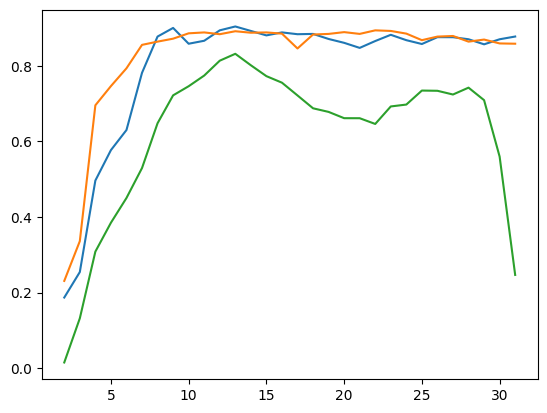

In [5]:
MODEL_NAME = 'llama-3-8b'
DATASET_NAME = 'cities_loc'
TASK = 3

for PROBE in ['mean_diff', 'spca', 'ttpd']:

    path = Path('outputs') / 'probes' / PROBE / MODEL_NAME /f'{ DATASET_NAME }_search_task-{str(TASK)}' / 'manifests'
    path.exists()


    res = load_stats(load_manifests(path))
    layers = sorted(res.keys())
    wmccs = [res[layer]for layer in layers]
    plt.plot(layers, wmccs)